In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import rasterio
from rasterio import plot
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import math
from sklearn.metrics import f1_score, precision_score, recall_score
from scipy.interpolate import griddata
import joblib
import seaborn as sns
import pandas as pd

sns.set_theme()

In [3]:
from utils.site import Site
from utils.tree import Tree
from utils.constants import GHANA_GDF, ETHZ_COCOA_MAP_THRESHOLDED_FILEPATH, ETHZ_COCOA_MAP_FILEPATH, SILVER_FOLDERPATH, ETHZ_COCOA_MAP_UINT8_FILEPATH

In [4]:
# Load sites
sites = Site.load_all()
print(f"Loaded {len(sites)} sites")

Loaded 155 sites


In [5]:
# Figure out all locations of interests
dfs = []
for s in sites:
    df = pd.DataFrame({
        'site_id': s.id,
        'lat_lons': s.lat_lons,
    })
    dfs.append(df)
df = pd.concat(dfs, axis=0)
df.head(1)

,site_id,lat_lons
0,AC01,"(5.754632, -1.182367)"


In [6]:
with rasterio.open(ETHZ_COCOA_MAP_FILEPATH) as src:
    print(f"Raster CRS: {src.crs}")
    lon_lats = df.lat_lons.apply(lambda x: (x[1], x[0])).to_list()

    vals = []
    for lon_lat, val in zip(lon_lats, src.sample(lon_lats)):
        # val comes back as an array matching the number of bands in the TIFF
        vals.append(float(val[0]))

df["probability"] = vals
df.head(1)

Raster CRS: EPSG:4326


,site_id,lat_lons,probability
0,AC01,"(5.754632, -1.182367)",0.925


Text(0.5, 1.0, 'ETHZ-probs histogram of the trees for each 775 trees')

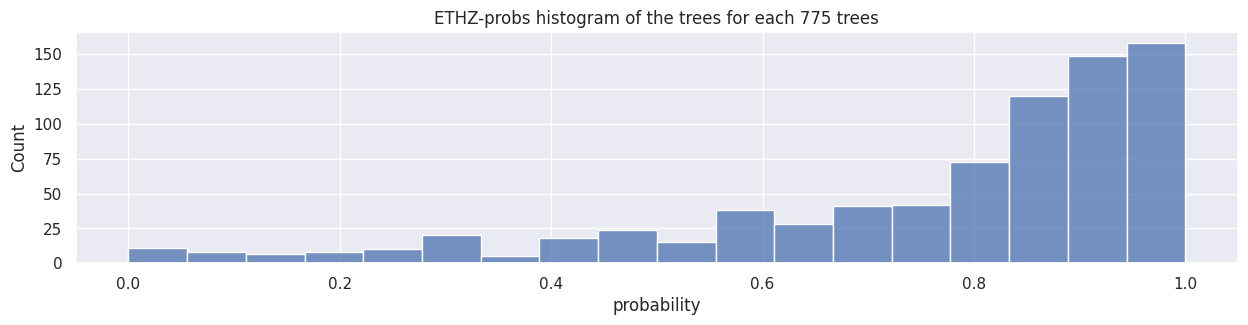

In [7]:
plt.figure(figsize=(15, 3))
sns.histplot(df.probability)
plt.title(f"ETHZ-probs histogram of the trees for each {len(df)} trees")

Text(0.5, 1.0, 'ETHZ-probs histogram of the max-pooling-amongst-trees for each 155 site')

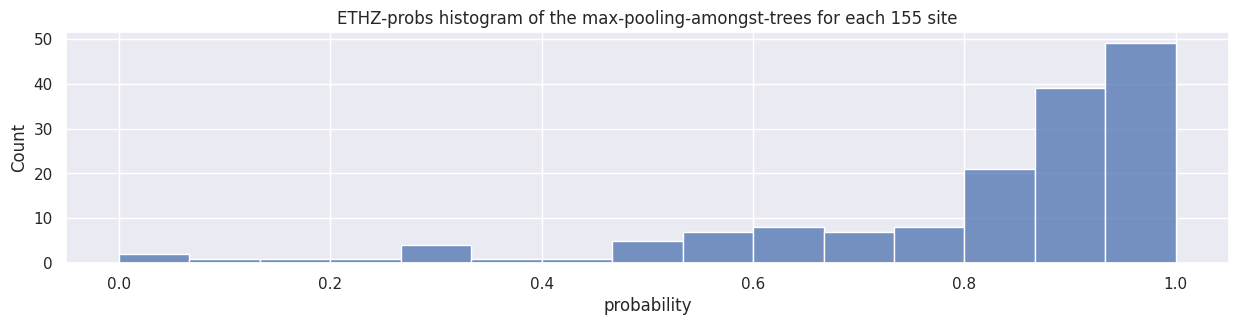

In [8]:
plt.figure(figsize=(15, 3))
sns.histplot(df.groupby('site_id').probability.max())
plt.title(f"ETHZ-probs histogram of the max-pooling-amongst-trees for each {len(sites)} site")

In [10]:
# What site are identified as no-cocoa ? 
grouped_df = df.groupby('site_id').max().sort_values(by='probability')
mask = grouped_df.probability <= 0.5
print(f"# no-cocoa sites: {mask.sum()}/{len(grouped_df)}")
grouped_df.probability[mask]

# no-cocoa sites: 14/155


site_id
KU06    0.000000
KU13    0.018519
SB13    0.071479
DU03    0.139583
SW11    0.223791
SB04    0.289542
HU08    0.293810
JU03    0.329011
SW02    0.332672
JU05    0.360859
AK08    0.421111
TP10    0.469145
BI03    0.471282
KU12    0.490000
Name: probability, dtype: float64

In [13]:
# What score would we have per tree ?
# Using a 0.5 threshold, we have 
yhat = df.probability >= 0.5
print(f"F1-score: {f1_score(np.full(shape=(len(df)), fill_value=1.0), yhat)}")
print(f"Precision: {precision_score(np.full(shape=(len(df)), fill_value=1.0), yhat)}")
print(f"Recall: {recall_score(np.full(shape=(len(df)), fill_value=1.0), yhat)}")


F1-score: 0.9228630993745657
Precision: 1.0
Recall: 0.8567741935483871
